In [1]:
# RGTransformer 验证与分析
# 说明：用于模型验证、预测可视化、区域分析
# 训练请使用: python src/RGT.py

%reload_ext autoreload
%autoreload 2

import sys
sys.path.append('X:/Workspace/3D-Ocean')

# 从配置文件导入（轻量级，不导入 PyTorch）
from src.trainer.config import (
    area, resolution, width, height,
    dataset_params, model_params
)
from src.trainer.base import BasePrediction
from src.models.SST.RGTransformer import RGTransformer
from src.dataset.OISST import OISSTDailyDataset
from src.config.params import PROJECT_PATH

print("✅ 库导入完成")
print(f"项目根目录: {PROJECT_PATH}")


✅ 库导入完成
项目根目录: X:/Workspace/3D-Ocean


In [ ]:
# %% 配置
# ⚠️ 只需修改 RUN_ID（训练时生成的时间戳）
# 其他配置自动从 src/trainer/config.py 导入

RUN_ID = "2026-02-04-14-58"  # 👈 修改为你的 run_id

print("=" * 70)
print("📋 配置（从 trainer/config.py 导入）")
print("=" * 70)
print(f"Run ID: {RUN_ID}")
print(f"区域: {area.title}")
print(f"分辨率: {resolution}°")
print(f"空间尺寸: {width} x {height}")
print("=" * 70)

📋 配置（从 trainer/config.py 导入）
Run ID: 2026-02-04-14-58
区域: Global
分辨率: 1°
空间尺寸: 360 x 160


In [3]:
# %% 1. 加载模型并预测
# 从 checkpoint 加载模型，进行预测和可视化

print("=" * 70)
print("📊 加载模型")
print("=" * 70)

# 创建预测器
predictor = BasePrediction(
    run_id=RUN_ID,  # 优先从本地 out/checkpoints/{run_id}/ 加载
    area=area,
    model_class=RGTransformer,
    dataset_class=OISSTDailyDataset,
    dataset_params=dataset_params,
    model_params=model_params,
)

# 预测并可视化
TEST_OFFSET = 1050  # 测试时间点

result = predictor.predict(offset=TEST_OFFSET, plot=True)
input_data, output_data, pred_output, rmse, r2, ssta = result

print(f"\n📈 预测结果:")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²: {r2:.4f}")
print("=" * 70)

📊 加载模型
[Load] From local checkpoint...
  - Run ID: 2026-02-04-14-58
  - 路径: X:/Workspace/3D-Ocean/out/checkpoints/2026-02-04-14-58/RGTransformer.ckpt
  [OK] Local checkpoint loaded
[OISSTDailyDataset] 数据天数: 2163
[OISSTDailyDataset] 时间范围: 2020-01-01 ~ 2025-12-07
[OISSTDailyDataset] 起始日期 (含offset): 2022-11-16
[OISSTDailyDataset] 原始经度范围: [-179.88, 179.88]
[OISSTDailyDataset] 原始纬度范围: [-89.88, 89.88]
[OISSTDailyDataset] 原始分辨率: 0.2500°
[OISSTDailyDataset] 目标分辨率: 1°
--------------------------------
Model: RGTransformer Prediction RMSE: 0.5273274183273315
NINO3.4 指数: 0.008°C
NINO3 指数: -0.111°C


wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: Currently logged in as: justgenius (justgenius-no) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[OK] Wandb 已重新初始化用于记录预测结果
  • Run ID: 2026-02-04-14-58
  • Run URL: https://wandb.ai/justgenius-no/3D-Ocean/runs/2026-02-04-14-58

📈 预测结果:
  RMSE: 0.5273
  R²: 0.9977


In [4]:
# %% 连续预测 (2025-12-01 ~ 2025-12-15)
# 绘制预测SST和误差分布图

import os
import numpy as np
import matplotlib.pyplot as plt
from cartopy import crs as ccrs
from matplotlib import cm as cm_plt
from datetime import datetime, timedelta
import arrow

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# 创建绘图函数
def plot_sst_prediction(true_sst, pred_sst, lon_range, lat_range, resolution, date_str, save_path):
    """
    绘制SST预测图：预测值和误差分布
    """
    fig = plt.figure(figsize=(14, 10))
    projection = ccrs.PlateCarree()
    
    # 生成网格
    lons = np.arange(lon_range[0], lon_range[1], resolution)
    lats = np.arange(lat_range[0], lat_range[1], resolution)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    # 计算误差
    error = pred_sst - true_sst
    rmse = np.sqrt(np.nanmean(error**2))
    
    # 1. 预测SST
    ax1 = fig.add_subplot(2, 1, 1, projection=projection)
    ax1.set_extent([*lon_range, *lat_range], crs=projection)
    ax1.coastlines(linewidth=0.5)
    ax1.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    im1 = ax1.contourf(lon_grid, lat_grid, pred_sst, levels=np.arange(0, 32, 1), 
                       cmap=cm_plt.jet, extend='both', transform=projection)
    plt.colorbar(im1, ax=ax1, orientation='vertical', label='Temperature (°C)', shrink=0.8)
    ax1.set_title(f'Predicted SST ({date_str})', fontsize=14, fontweight='bold')
    
    # 2. 误差分布
    ax2 = fig.add_subplot(2, 1, 2, projection=projection)
    ax2.set_extent([*lon_range, *lat_range], crs=projection)
    ax2.coastlines(linewidth=0.5)
    ax2.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    abs_max = min(np.nanmax(np.abs(error)), 2.0)
    levels_err = np.linspace(-abs_max, abs_max, 21)
    im2 = ax2.contourf(lon_grid, lat_grid, error, levels=levels_err, 
                       cmap='RdBu_r', extend='both', transform=projection)
    plt.colorbar(im2, ax=ax2, orientation='vertical', label='Error (°C)', shrink=0.8)
    ax2.set_title(f'Prediction Error (RMSE: {rmse:.4f}°C)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    
    return rmse

# ============================================================
# 预测配置
# ============================================================
print("=" * 70)
print("🌊 连续预测配置")
print("=" * 70)

# 目标预测范围
target_start_date = datetime(2025, 11, 20)
target_end_date = datetime(2025, 11, 30)
target_days = (target_end_date - target_start_date).days + 1  # 11天

# 首先创建一个临时数据集来获取准确的时间范围
temp_dataset = OISSTDailyDataset(
    seq_len=dataset_params.get('seq_len', 2),
    offset=0,
    lon=area.lon,
    lat=area.lat,
    resolution=dataset_params.get('resolution', 1)
)

# 获取数据集的实际时间范围（转换为naive datetime，去除时区信息）
data_start = temp_dataset.start_time.naive
data_end = temp_dataset.end_time.naive
seq_len = dataset_params.get('seq_len', 2)
total_days = len(temp_dataset._files)

print(f"数据集时间范围: {data_start.strftime('%Y-%m-%d')} ~ {data_end.strftime('%Y-%m-%d')}")
print(f"数据集天数: {total_days}")
print(f"序列长度: {seq_len}")

# 计算有效的预测范围
# offset 从 0 到 (total_days - seq_len - 1) 是有效的
# 预测的日期是 data_start + offset + seq_len - 1
max_offset = total_days - seq_len - 1
max_pred_date = data_start + timedelta(days=max_offset + seq_len - 1)

print(f"最大有效offset: {max_offset}")
print(f"最大可预测日期: {max_pred_date.strftime('%Y-%m-%d')}")

# 计算目标日期对应的offset
# 预测日期 = data_start + offset + seq_len - 1
# offset = (预测日期 - data_start).days - seq_len + 1
start_offset = (target_start_date - data_start).days - seq_len + 1
end_offset = (target_end_date - data_start).days - seq_len + 1

# 限制在有效范围内
start_offset = max(0, start_offset)
end_offset = min(max_offset, end_offset)
actual_days = end_offset - start_offset + 1

actual_start_date = data_start + timedelta(days=start_offset + seq_len - 1)
actual_end_date = data_start + timedelta(days=end_offset + seq_len - 1)

print(f"\n目标预测: {target_start_date.strftime('%Y-%m-%d')} ~ {target_end_date.strftime('%Y-%m-%d')} ({target_days}天)")
print(f"实际预测: {actual_start_date.strftime('%Y-%m-%d')} ~ {actual_end_date.strftime('%Y-%m-%d')} ({actual_days}天)")

if actual_days < target_days:
    print(f"⚠️  数据限制：只能预测 {actual_days} 天")

# 创建预测器
print("\n" + "=" * 70)
print("🚀 开始预测")
print("=" * 70)

predictor = BasePrediction(
    run_id=RUN_ID,
    area=area,
    model_class=RGTransformer,
    dataset_class=OISSTDailyDataset,
    dataset_params=dataset_params,
    model_params=model_params,
)

# 输出目录
output_dir = os.path.join(PROJECT_PATH, 'out/sst/prediction_2025_11')
os.makedirs(output_dir, exist_ok=True)

# 连续预测
results = []
print(f"输出目录: {output_dir}\n")

for i in range(actual_days):
    offset = start_offset + i
    pred_date = data_start + timedelta(days=offset + seq_len - 1)
    date_str = pred_date.strftime("%Y-%m-%d")
    
    # 预测
    result = predictor.predict(offset=offset, plot=False)
    input_data, true_sst, pred_sst, rmse, r2, ssta = result
    
    # 保存图像
    filename = f"sst_pred_{date_str}.png"
    save_path = os.path.join(output_dir, filename)
    rmse_val = plot_sst_prediction(true_sst, pred_sst, area.lon, area.lat, resolution, date_str, save_path)
    
    results.append({
        'date': date_str,
        'rmse': rmse,
        'r2': r2
    })
    
    print(f"  [{i+1:02d}/{actual_days:02d}] {date_str} | RMSE: {rmse:.4f}°C | R²: {r2:.4f} | ✓ 已保存")

# 汇总统计
print("\n" + "=" * 70)
print(f"📊 {actual_days}天预测汇总")
print("=" * 70)
avg_rmse = np.mean([r['rmse'] for r in results])
avg_r2 = np.mean([r['r2'] for r in results])
print(f"  平均 RMSE: {avg_rmse:.4f}°C")
print(f"  平均 R²:   {avg_r2:.4f}")
print(f"\n✅ 所有图像已保存至: {output_dir}")

🌊 连续预测配置
[OISSTDailyDataset] 数据天数: 2163
[OISSTDailyDataset] 时间范围: 2020-01-01 ~ 2025-12-07
[OISSTDailyDataset] 起始日期 (含offset): 2020-01-01
[OISSTDailyDataset] 原始经度范围: [-179.88, 179.88]
[OISSTDailyDataset] 原始纬度范围: [-89.88, 89.88]
[OISSTDailyDataset] 原始分辨率: 0.2500°
[OISSTDailyDataset] 目标分辨率: 1°
数据集时间范围: 2020-01-01 ~ 2025-12-07
数据集天数: 2163
序列长度: 2
最大有效offset: 2160
最大可预测日期: 2025-12-01

目标预测: 2025-11-20 ~ 2025-11-30 (11天)
实际预测: 2025-11-20 ~ 2025-11-30 (11天)

🚀 开始预测
输出目录: X:/Workspace/3D-Ocean\out/sst/prediction_2025_11

[Load] From local checkpoint...
  - Run ID: 2026-02-04-14-58
  - 路径: X:/Workspace/3D-Ocean/out/checkpoints/2026-02-04-14-58/RGTransformer.ckpt
  [OK] Local checkpoint loaded
[OISSTDailyDataset] 数据天数: 2163
[OISSTDailyDataset] 时间范围: 2020-01-01 ~ 2025-12-07
[OISSTDailyDataset] 起始日期 (含offset): 2025-11-19
[OISSTDailyDataset] 原始经度范围: [-179.88, 179.88]
[OISSTDailyDataset] 原始纬度范围: [-89.88, 89.88]
[OISSTDailyDataset] 原始分辨率: 0.2500°
[OISSTDailyDataset] 目标分辨率: 1°
------------------------

In [5]:
# %% 各海域预测性能对比表
# 基于 2025-11-20 ~ 2025-11-30 的多天预测结果，生成各海域性能汇总表

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from src.analysis.regional import RegionalAnalysis, OCEAN_REGIONS

print("=" * 80)
print("🌊 全球各海域预测性能对比分析")
print("=" * 80)

# 使用之前创建的数据集信息
# 重新计算预测范围（与上个cell一致）
target_start_date = datetime(2025, 11, 20)
target_end_date = datetime(2025, 11, 30)

# 计算 offset 范围
start_offset = (target_start_date - data_start).days - seq_len + 1
end_offset = (target_end_date - data_start).days - seq_len + 1
start_offset = max(0, start_offset)
end_offset = min(max_offset, end_offset)
actual_days = end_offset - start_offset + 1

print(f"分析时间范围: {target_start_date.strftime('%Y-%m-%d')} ~ {target_end_date.strftime('%Y-%m-%d')}")
print(f"实际分析天数: {actual_days} 天")
print()

# 存储每天每个区域的指标
all_region_stats = {region_key: [] for region_key in OCEAN_REGIONS.keys()}
daily_global_stats = []

# 对每一天进行分析
for i in range(actual_days):
    offset = start_offset + i
    pred_date = data_start + timedelta(days=offset + seq_len - 1)
    date_str = pred_date.strftime("%Y-%m-%d")
    
    # 预测
    result = predictor.predict(offset=offset, plot=False)
    _, true_sst, pred_sst, global_rmse, global_r2, ssta = result
    
    # 全球统计
    daily_global_stats.append({
        'date': date_str,
        'global_rmse': global_rmse,
        'global_r2': global_r2
    })
    
    # 创建区域分析器
    analyzer = RegionalAnalysis(
        pred_output=pred_sst,
        true_output=true_sst,
        lon=area.lon,
        lat=area.lat,
        resolution=resolution,
        ssta=ssta
    )
    
    # 计算每个区域的统计指标
    for region_key in OCEAN_REGIONS.keys():
        stats = analyzer.compute_region_stats(region_key)
        if stats['valid']:
            all_region_stats[region_key].append({
                'date': date_str,
                'rmse': stats['rmse'],
                'mae': stats['mae'],
                'r2': stats['r2'],
                'bias': stats['bias'],
                'true_mean': stats['true_mean'],
                'pred_mean': stats['pred_mean']
            })
    
    print(f"  ✓ {date_str} 分析完成")

print(f"\n{'=' * 80}")
print("📊 生成汇总表格")
print("=" * 80)

# 汇总各区域的平均指标
summary_data = []

for region_key, stats_list in all_region_stats.items():
    if len(stats_list) > 0:
        region_info = OCEAN_REGIONS[region_key]
        avg_rmse = np.mean([s['rmse'] for s in stats_list])
        avg_mae = np.mean([s['mae'] for s in stats_list])
        avg_r2 = np.mean([s['r2'] for s in stats_list])
        avg_bias = np.mean([s['bias'] for s in stats_list])
        avg_true_temp = np.mean([s['true_mean'] for s in stats_list])
        
        # RMSE 的标准差（表示稳定性）
        std_rmse = np.std([s['rmse'] for s in stats_list])
        
        summary_data.append({
            '海域': region_info['name_cn'],
            '英文名': region_info['name'],
            '经度范围': f"{region_info['lon'][0]}° ~ {region_info['lon'][1]}°",
            '纬度范围': f"{region_info['lat'][0]}° ~ {region_info['lat'][1]}°",
            '平均RMSE (°C)': avg_rmse,
            'RMSE标准差': std_rmse,
            '平均MAE (°C)': avg_mae,
            '平均R²': avg_r2,
            '平均偏差 (°C)': avg_bias,
            '平均温度 (°C)': avg_true_temp,
        })

# 创建 DataFrame 并按 RMSE 排序
df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values(by='平均RMSE (°C)')

# 添加全球平均
global_avg_rmse = np.mean([s['global_rmse'] for s in daily_global_stats])
global_avg_r2 = np.mean([s['global_r2'] for s in daily_global_stats])

print(f"\n🌍 全球平均性能 ({actual_days}天平均):")
print(f"   RMSE: {global_avg_rmse:.4f}°C")
print(f"   R²:   {global_avg_r2:.4f}")

# 保存到CSV
output_csv = os.path.join(PROJECT_PATH, 'out/sst/prediction_2025_11/regional_performance_summary.csv')
df_summary.to_csv(output_csv, index=False, encoding='utf-8-sig')
print(f"\n✅ 汇总表已保存: {output_csv}")

# 格式化显示
print(f"\n{'=' * 100}")
print(f"📋 各海域预测性能对比表 ({target_start_date.strftime('%Y-%m-%d')} ~ {actual_end_date.strftime('%Y-%m-%d')})")
print("=" * 100)

# 格式化输出
df_display = df_summary.copy()
df_display['平均RMSE (°C)'] = df_display['平均RMSE (°C)'].apply(lambda x: f'{x:.4f}')
df_display['RMSE标准差'] = df_display['RMSE标准差'].apply(lambda x: f'{x:.4f}')
df_display['平均MAE (°C)'] = df_display['平均MAE (°C)'].apply(lambda x: f'{x:.4f}')
df_display['平均R²'] = df_display['平均R²'].apply(lambda x: f'{x:.4f}')
df_display['平均偏差 (°C)'] = df_display['平均偏差 (°C)'].apply(lambda x: f'{x:+.4f}')
df_display['平均温度 (°C)'] = df_display['平均温度 (°C)'].apply(lambda x: f'{x:.2f}')

print(df_display.to_string(index=False))
print("=" * 100)

# 最佳和最差区域
best_region = df_summary.iloc[0]['海域']
worst_region = df_summary.iloc[-1]['海域']
print(f"\n✅ 预测效果最好: {best_region} (RMSE={df_summary.iloc[0]['平均RMSE (°C)']:.4f}°C)")
print(f"⚠️  预测效果最差: {worst_region} (RMSE={df_summary.iloc[-1]['平均RMSE (°C)']:.4f}°C)")

# 显示 DataFrame（在 Jupyter 中美观显示）
print("\n📊 表格数据 (DataFrame):")
df_summary

🌊 全球各海域预测性能对比分析
分析时间范围: 2025-11-20 ~ 2025-11-30
实际分析天数: 11 天

[OISSTDailyDataset] 数据天数: 2163
[OISSTDailyDataset] 时间范围: 2020-01-01 ~ 2025-12-07
[OISSTDailyDataset] 起始日期 (含offset): 2025-11-19
[OISSTDailyDataset] 原始经度范围: [-179.88, 179.88]
[OISSTDailyDataset] 原始纬度范围: [-89.88, 89.88]
[OISSTDailyDataset] 原始分辨率: 0.2500°
[OISSTDailyDataset] 目标分辨率: 1°
--------------------------------
Model: RGTransformer Prediction RMSE: 0.5371330976486206
  ✓ 2025-11-20 分析完成
[OISSTDailyDataset] 数据天数: 2163
[OISSTDailyDataset] 时间范围: 2020-01-01 ~ 2025-12-07
[OISSTDailyDataset] 起始日期 (含offset): 2025-11-20
[OISSTDailyDataset] 原始经度范围: [-179.88, 179.88]
[OISSTDailyDataset] 原始纬度范围: [-89.88, 89.88]
[OISSTDailyDataset] 原始分辨率: 0.2500°
[OISSTDailyDataset] 目标分辨率: 1°
--------------------------------
Model: RGTransformer Prediction RMSE: 0.5423383712768555
  ✓ 2025-11-21 分析完成
[OISSTDailyDataset] 数据天数: 2163
[OISSTDailyDataset] 时间范围: 2020-01-01 ~ 2025-12-07
[OISSTDailyDataset] 起始日期 (含offset): 2025-11-21
[OISSTDailyDataset] 原始经度

,海域,英文名,经度范围,纬度范围,平均RMSE (°C),RMSE标准差,平均MAE (°C),平均R²,平均偏差 (°C),平均温度 (°C)
2,赤道太平洋暖池,Western Pacific Warm Pool,120° ~ 180°,-5° ~ 5°,0.469762,0.022481,0.401785,0.408185,0.293058,29.707636
0,厄尔尼诺监测区,NINO 3.4,-170° ~ -120°,-5° ~ 5°,0.541011,0.026291,0.443309,0.795191,0.297088,26.070726
1,东太平洋暖池,NINO 3,-150° ~ -90°,-5° ~ 5°,0.558998,0.016344,0.437080,0.889545,0.203641,24.584444
5,南大洋西风漂流,Antarctic Circumpolar Current,-180° ~ 180°,-60° ~ -40°,0.563168,0.017924,0.442725,0.984143,-0.320500,6.377475
6,北印度洋,North Indian Ocean,50° ~ 100°,0° ~ 25°,0.589551,0.025142,0.518877,0.550712,0.494817,28.132648
7,北大西洋副极地,North Atlantic Subpolar,-60° ~ -10°,45° ~ 65°,0.675067,0.022663,0.495545,0.966867,-0.178386,9.533409
4,黑潮区域,Kuroshio Current,125° ~ 170°,25° ~ 40°,0.887311,0.053725,0.687408,0.926710,0.459177,22.703209
3,墨西哥湾暖流,Gulf Stream,-80° ~ -40°,25° ~ 45°,1.089608,0.055637,0.722717,0.940351,0.420414,22.130510


🌊 区域性分析

🌊 海洋区域性分析
分析区域: Global
空间分辨率: 1°
测试时间点: 1050
保存目录: out/sst/regional

📊 正在对时间点 1050 进行详细分析...
[OISSTDailyDataset] 数据天数: 2163
[OISSTDailyDataset] 时间范围: 2020-01-01 ~ 2025-12-07
[OISSTDailyDataset] 起始日期 (含offset): 2022-11-16
[OISSTDailyDataset] 原始经度范围: [-179.88, 179.88]
[OISSTDailyDataset] 原始纬度范围: [-89.88, 89.88]
[OISSTDailyDataset] 原始分辨率: 0.2500°
[OISSTDailyDataset] 目标分辨率: 1°
--------------------------------
Model: RGTransformer Prediction RMSE: 0.5273274183273315

🌍 全球预测性能: RMSE=0.5273°C, R²=0.9977

📊 海洋区域分析报告

▶ 厄尔尼诺监测区 (NINO 3.4)
  经度范围: -170° ~ -120°
  纬度范围: -5° ~ 5°
  有效像素: 505
------------------------------------------------------------
  【温度统计】
    真实值 - 均值: 25.67°C, 标准差: 1.37°C, 范围: [21.79, 28.48]°C
    预测值 - 均值: 25.98°C, 标准差: 1.42°C, 范围: [21.48, 28.64]°C
  【误差分析】
    RMSE: 0.4929°C
    MAE: 0.4148°C
    系统偏差 (Bias): +0.3122°C
    R²: 0.8703
    误差范围: [-0.847, 1.528]°C
  【温度异常 (SSTA)】
    均值: +0.008°C, 标准差: 0.531°C
  【区域特征】
    厄尔尼诺/拉尼娜现象的核心监测区域，海表温度异常直接反映ENSO状态

▶ 东太平洋暖池

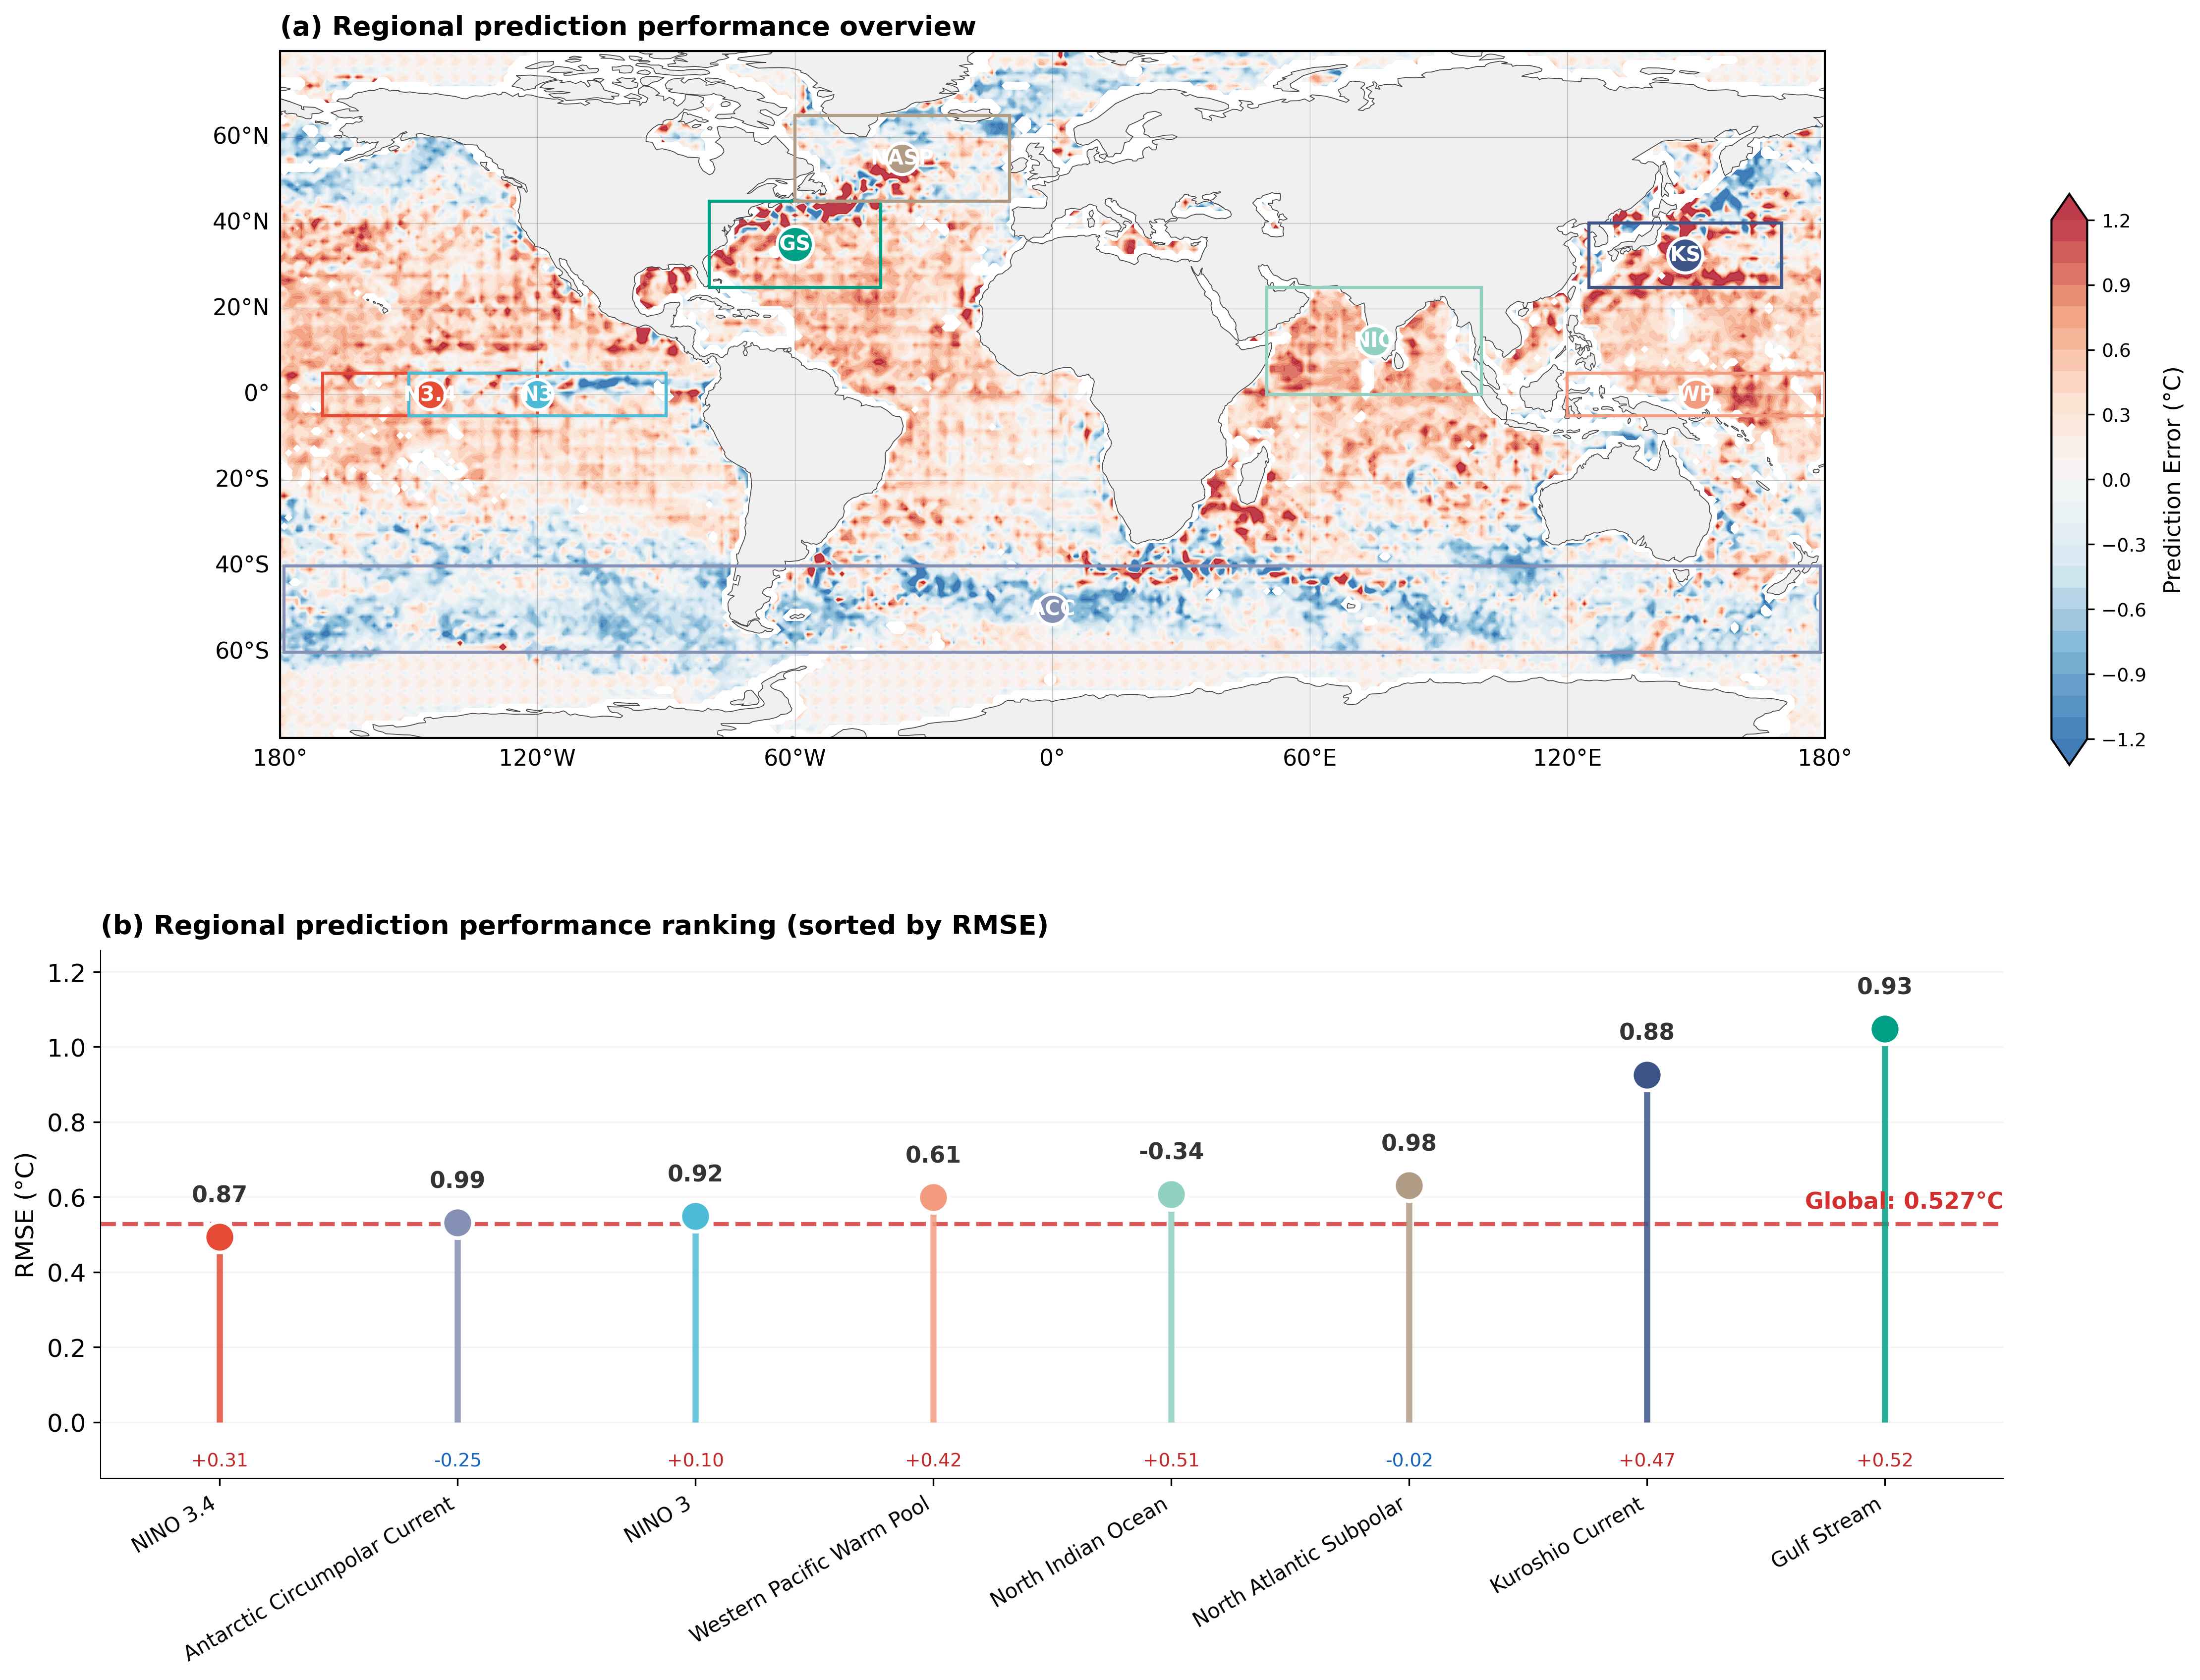


🔍 正在生成各区域详细分析图...
⚠️  区域 nino34 分析失败: 'transform' is not allowed as a keyword argument; axhline generates its own transform.
⚠️  区域 gulf_stream 分析失败: 'transform' is not allowed as a keyword argument; axhline generates its own transform.
⚠️  区域 kuroshio 分析失败: 'transform' is not allowed as a keyword argument; axhline generates its own transform.
⚠️  区域 acc 分析失败: 'transform' is not allowed as a keyword argument; axhline generates its own transform.
⚠️  区域 warm_pool 分析失败: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

📋 正在生成汇总表格...
✅ 汇总表格已保存: out/sst/regional/regional_analysis_summary.csv

📊 各海域预测性能汇总（按 RMSE 排序）:
----------------------------------------------------------------------------------------------------
     区域                           英文名 RMSE (°C) MAE (°C)      R² 系统偏差 (°C) 真实温度均值 (°C) 空间变异性 (°C)
厄尔尼诺监测区                      NINO 3.4    0.4929   0.4148  0.8703   +0.3122       25.67      1.368
南大洋西风漂流 Antarctic Circumpolar Current    0.5

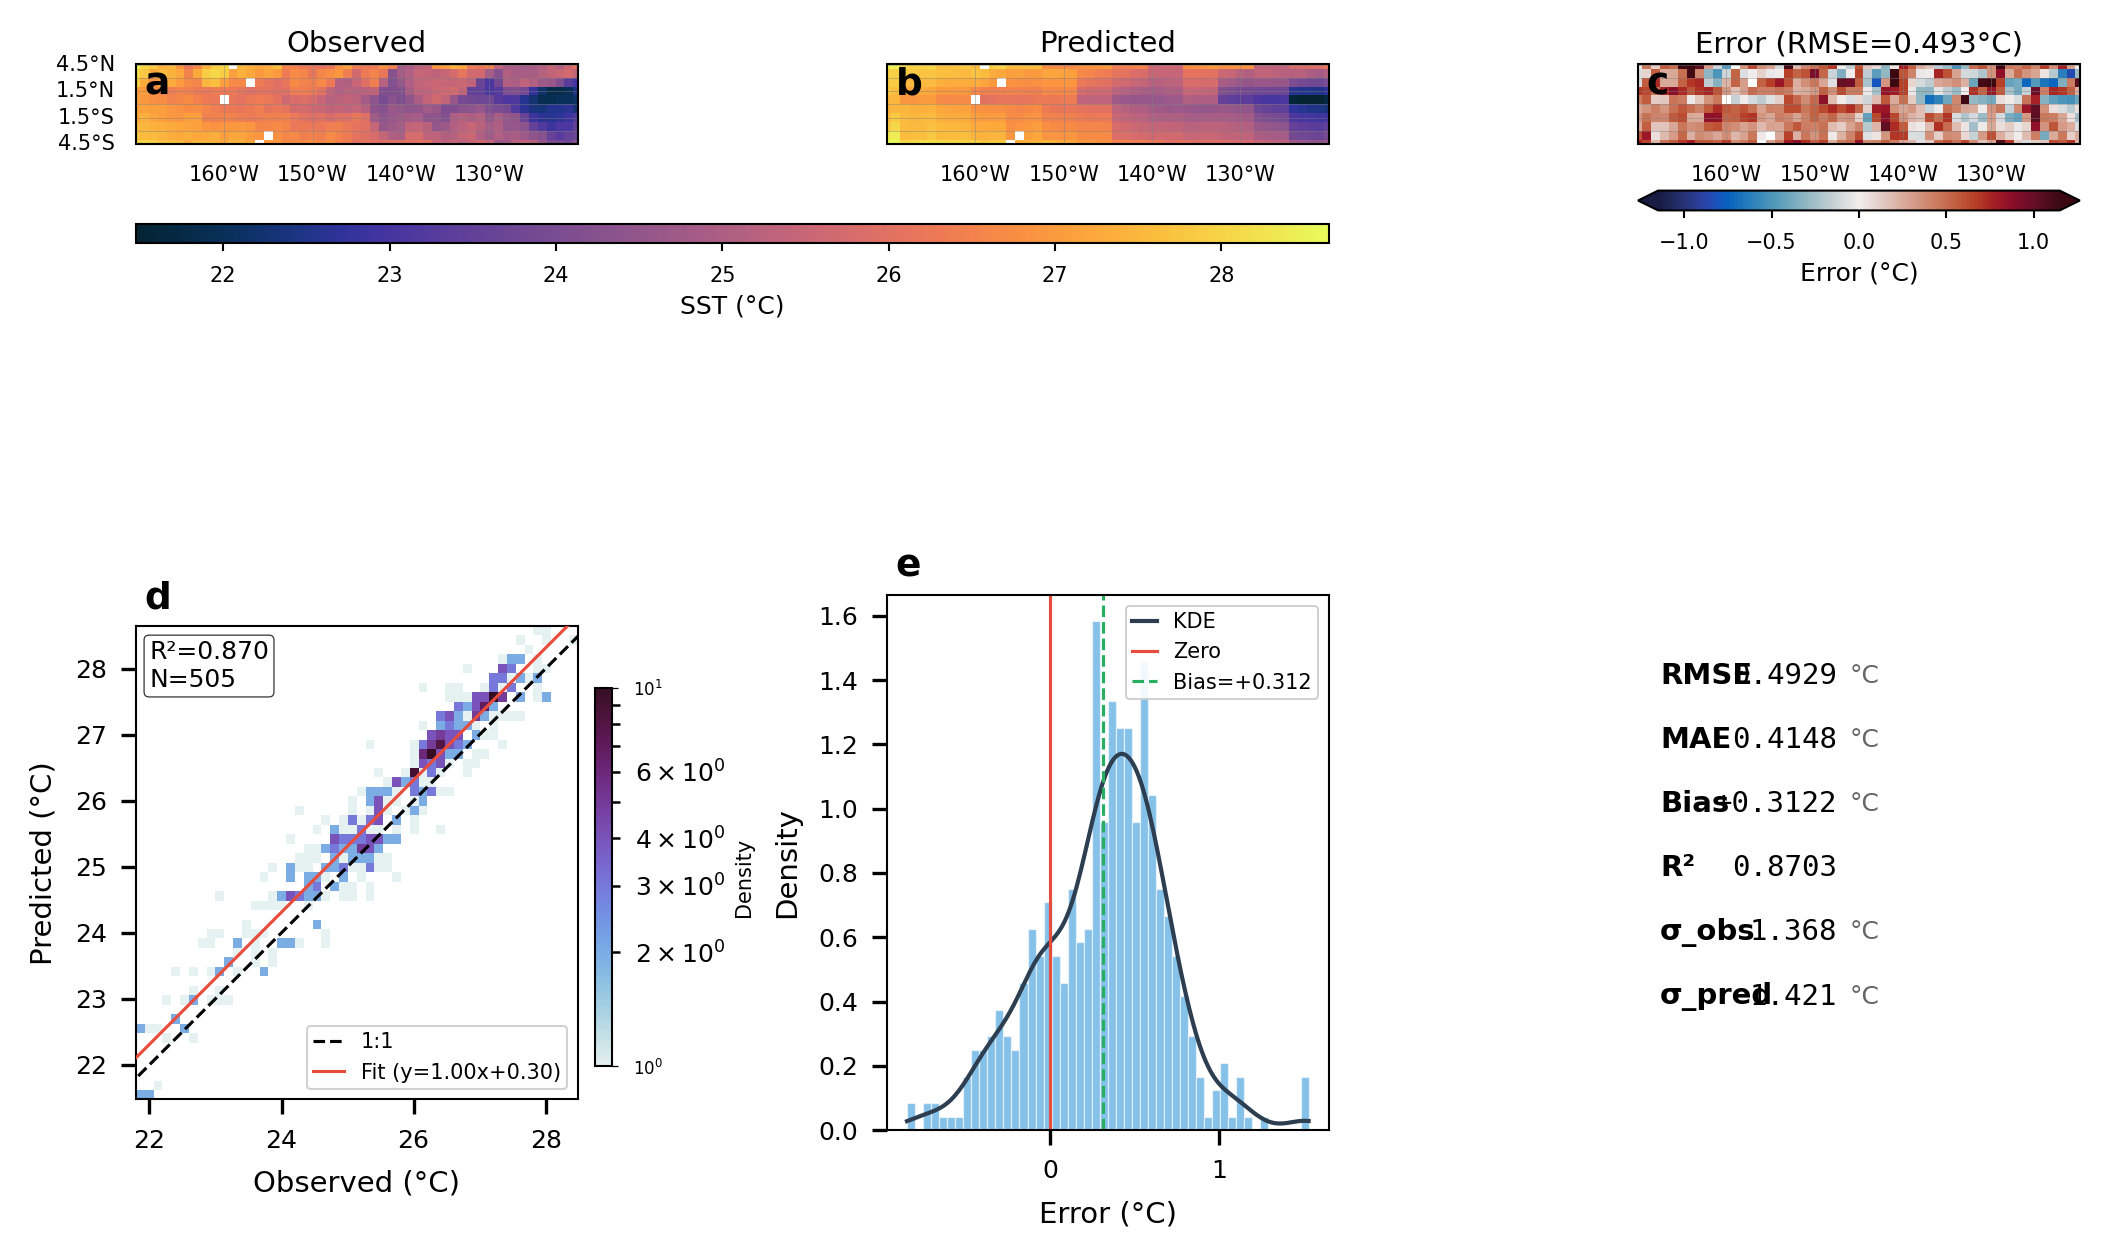

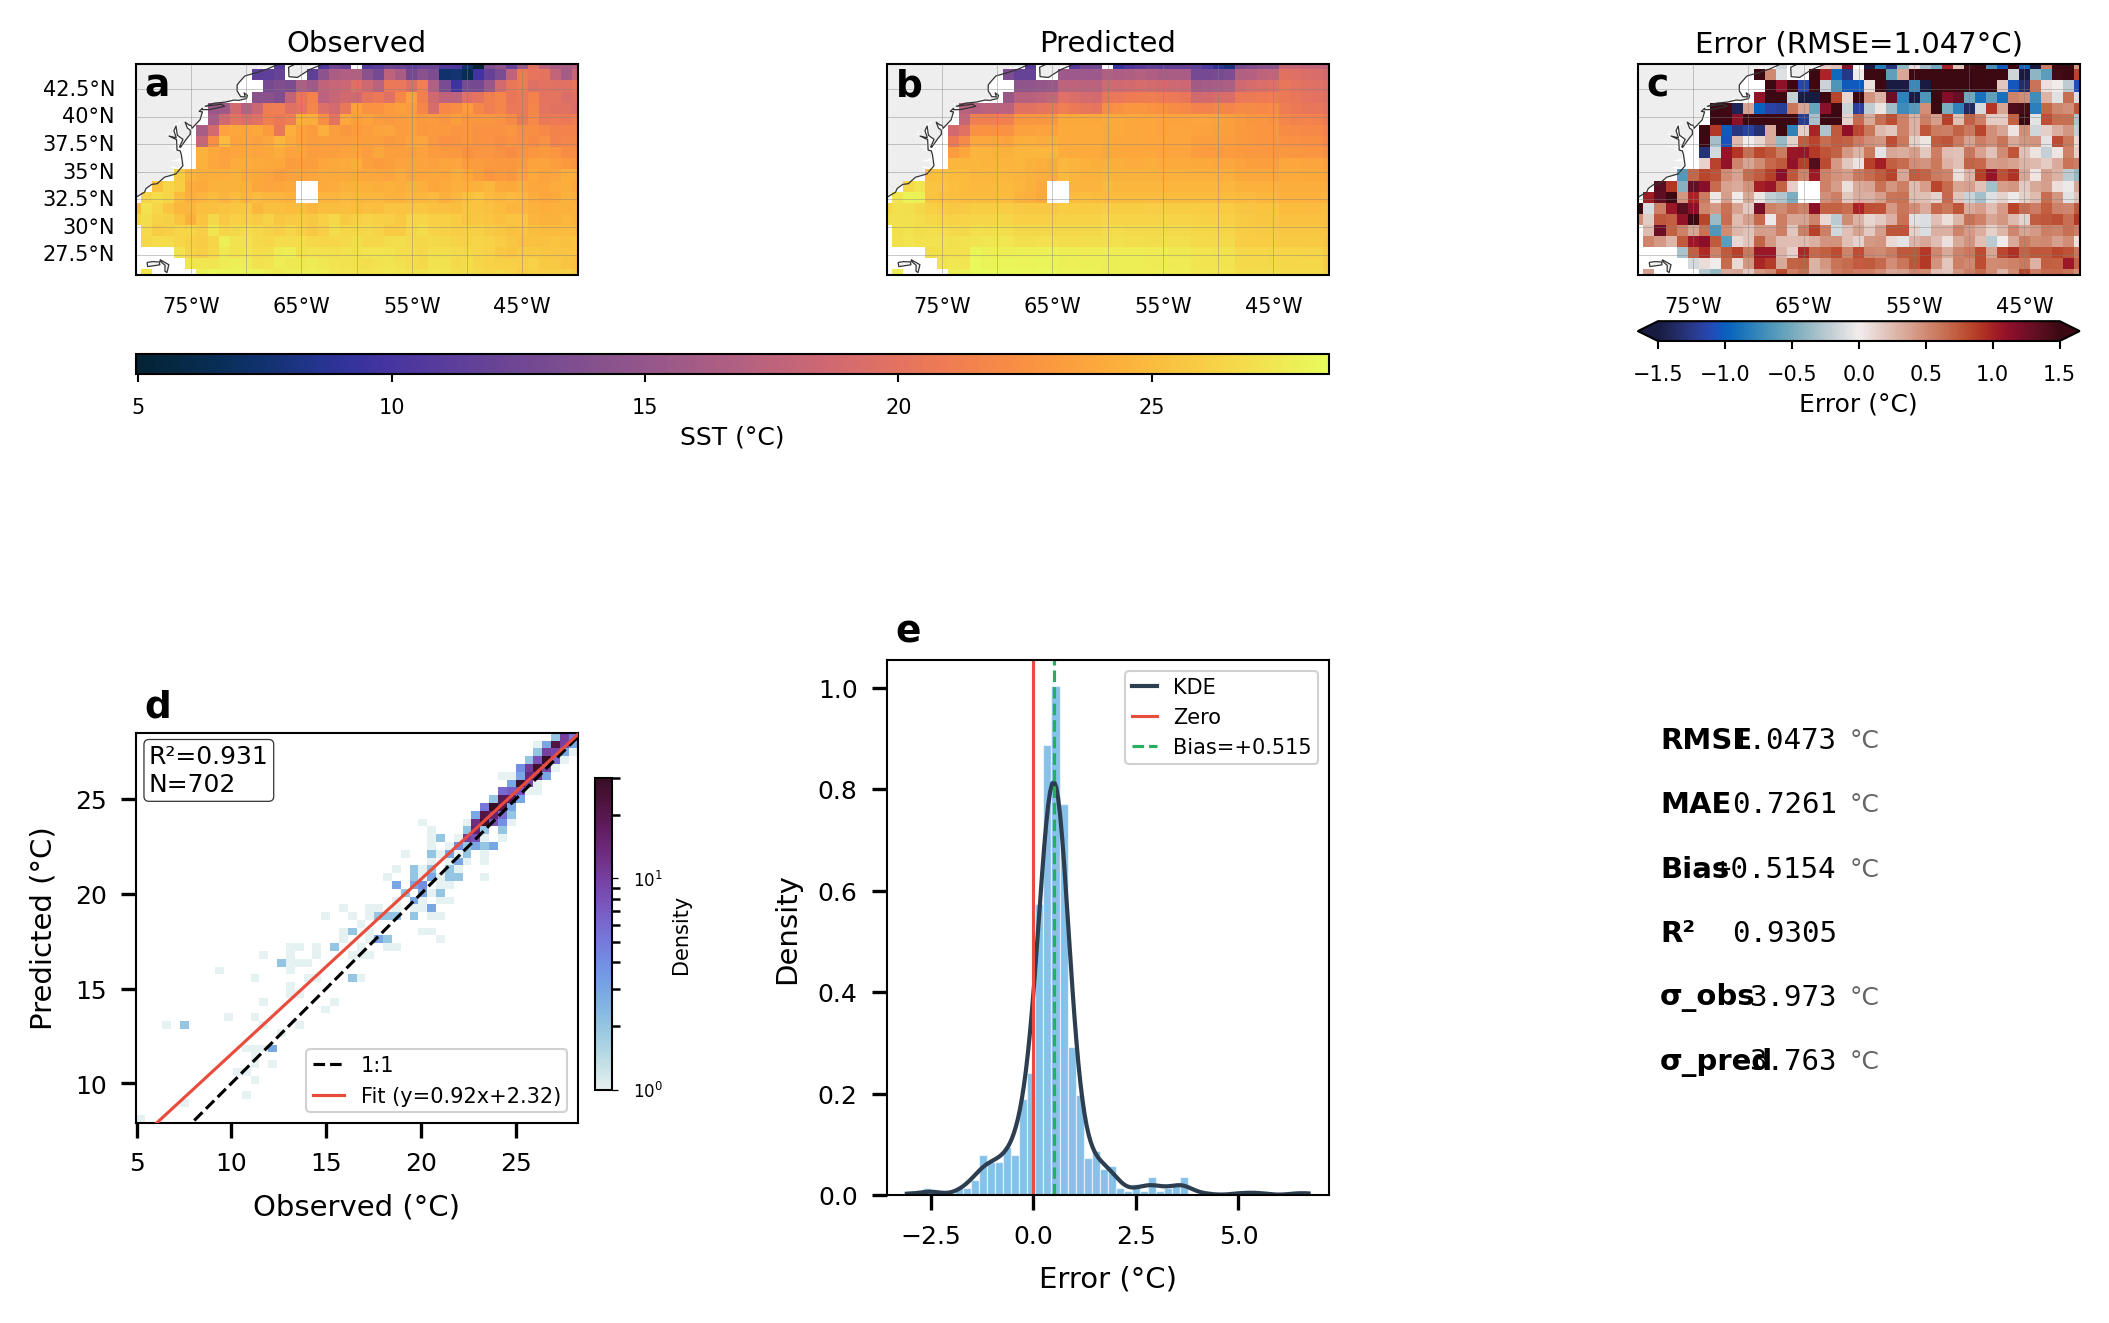

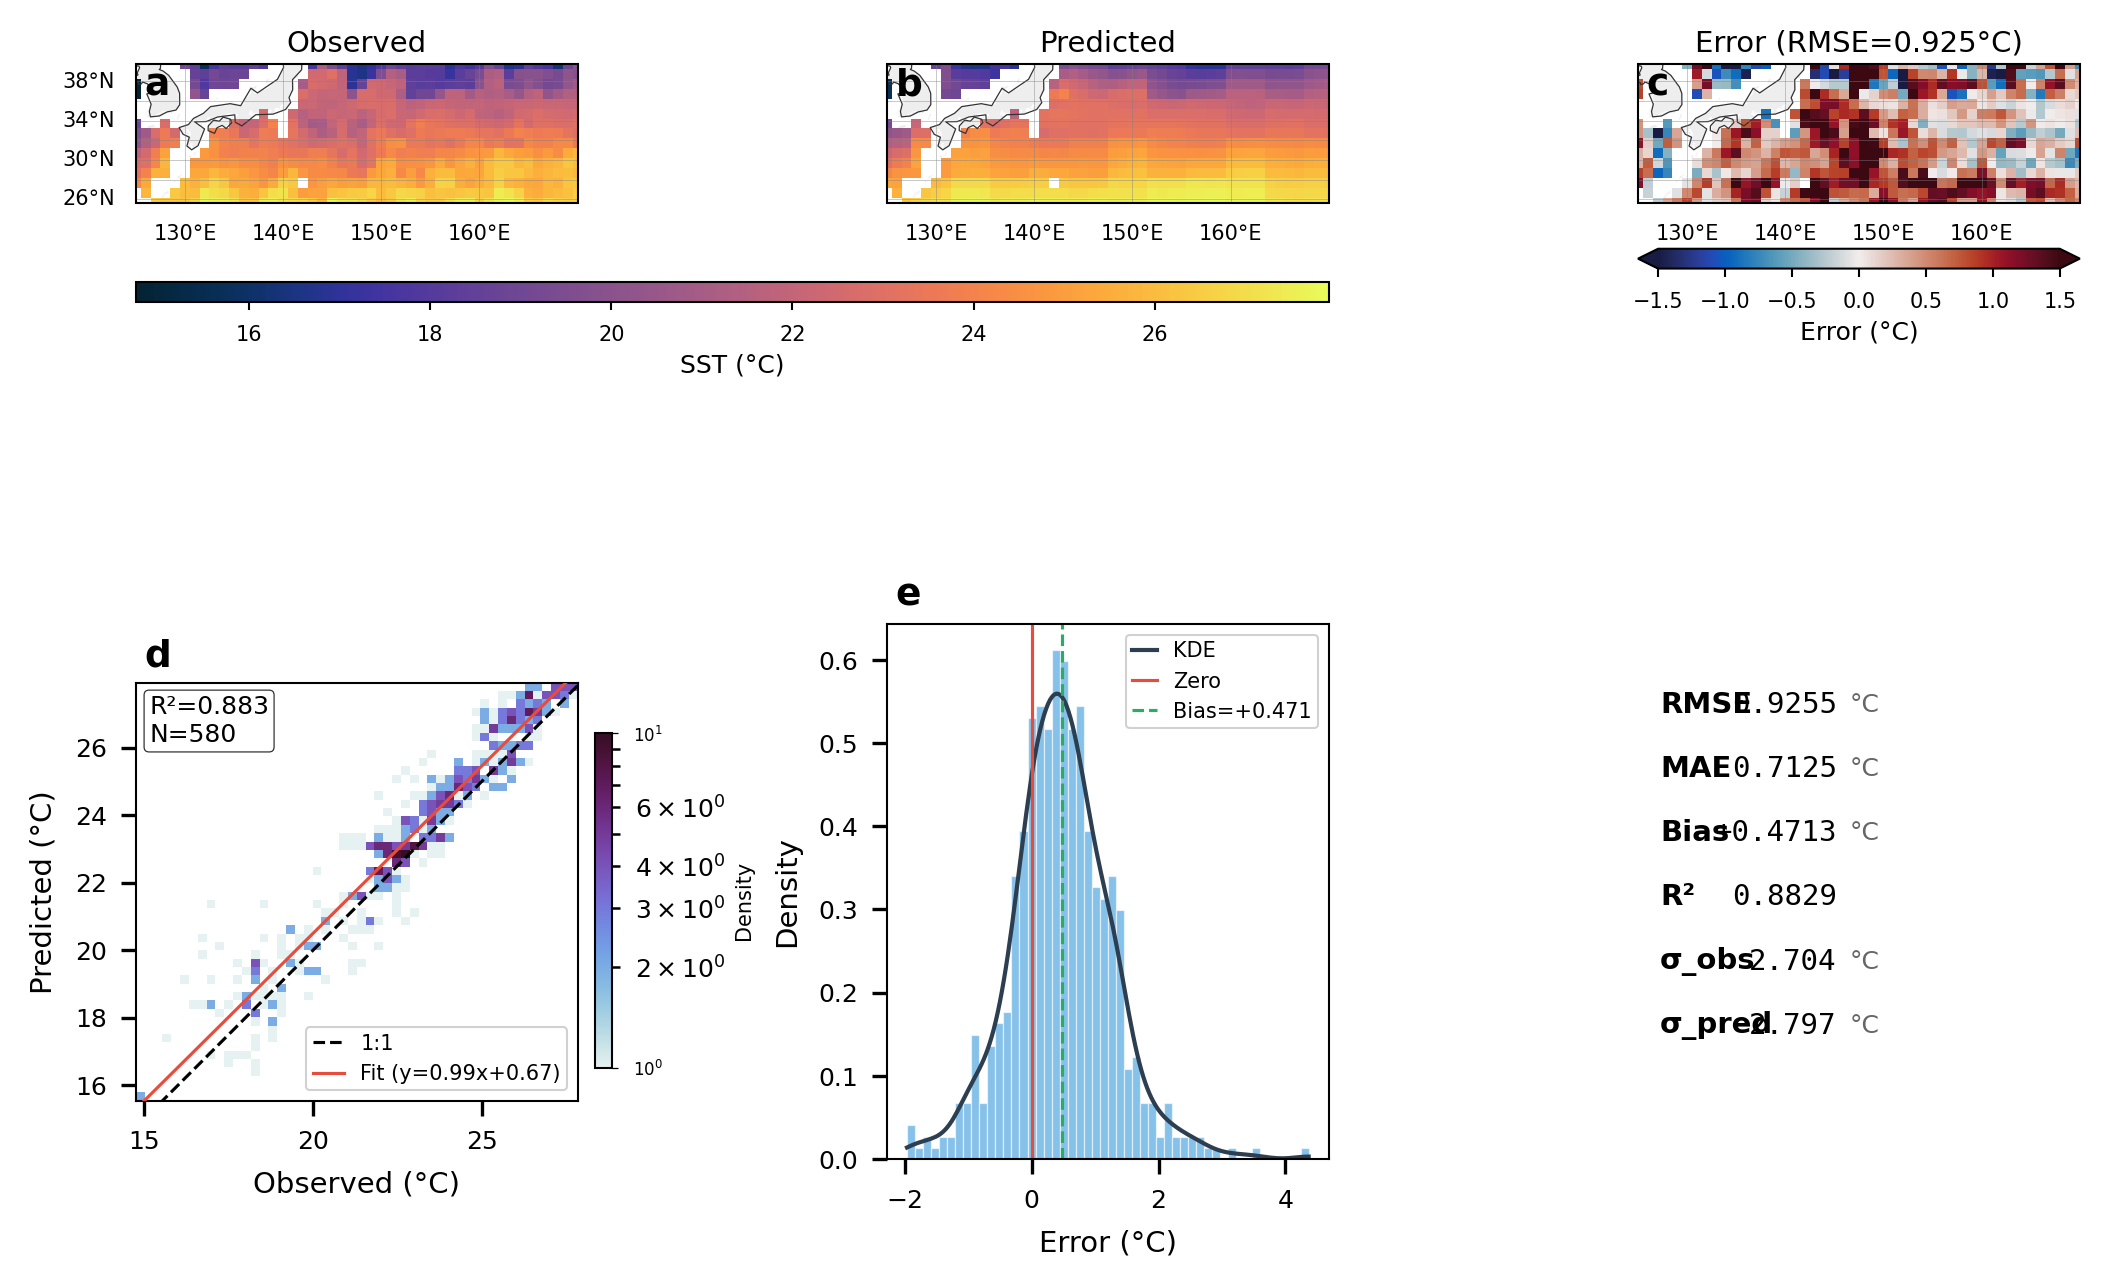

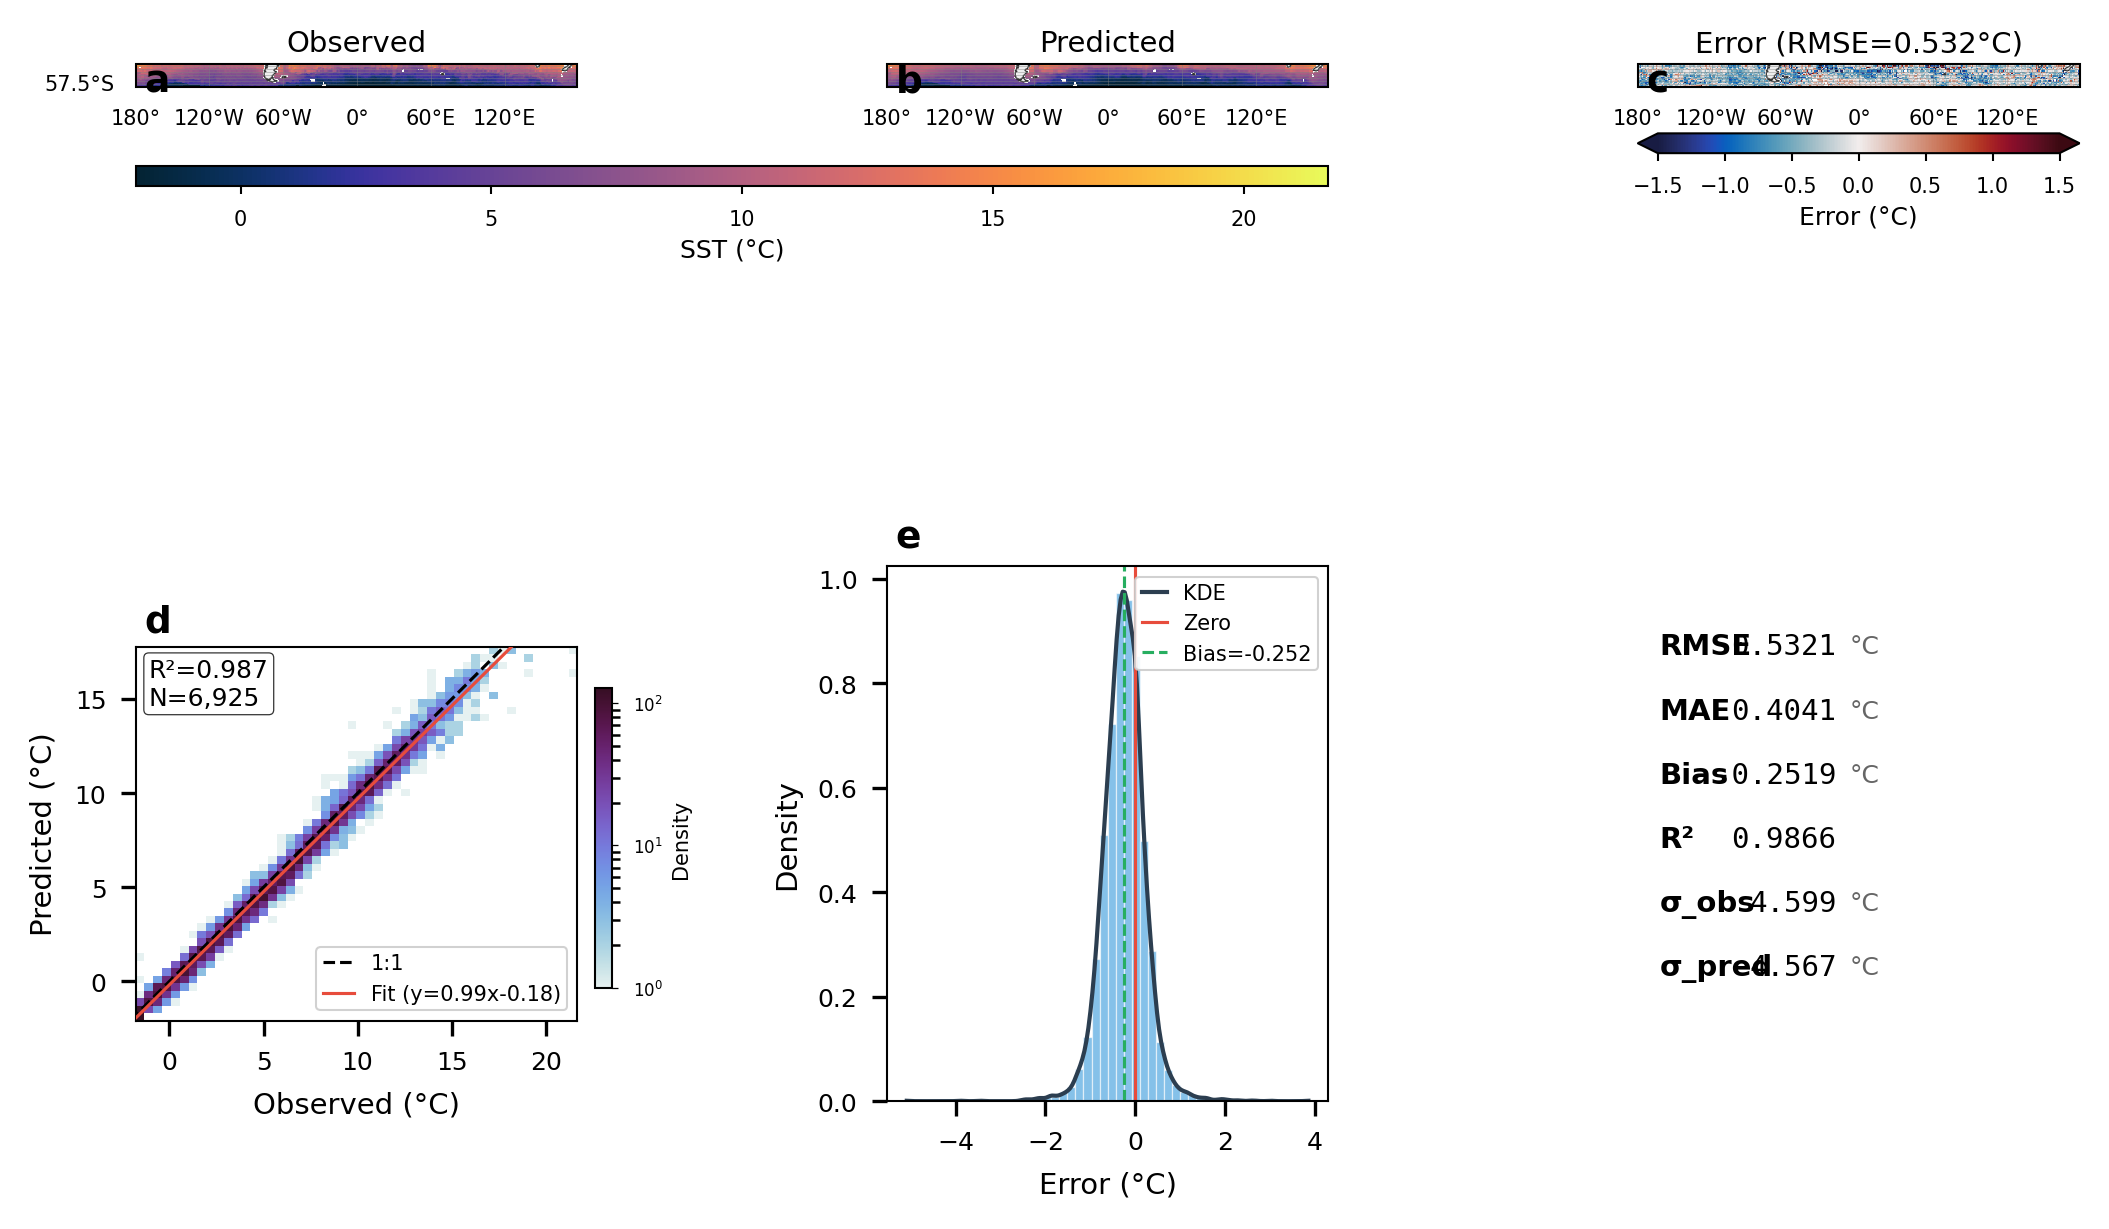

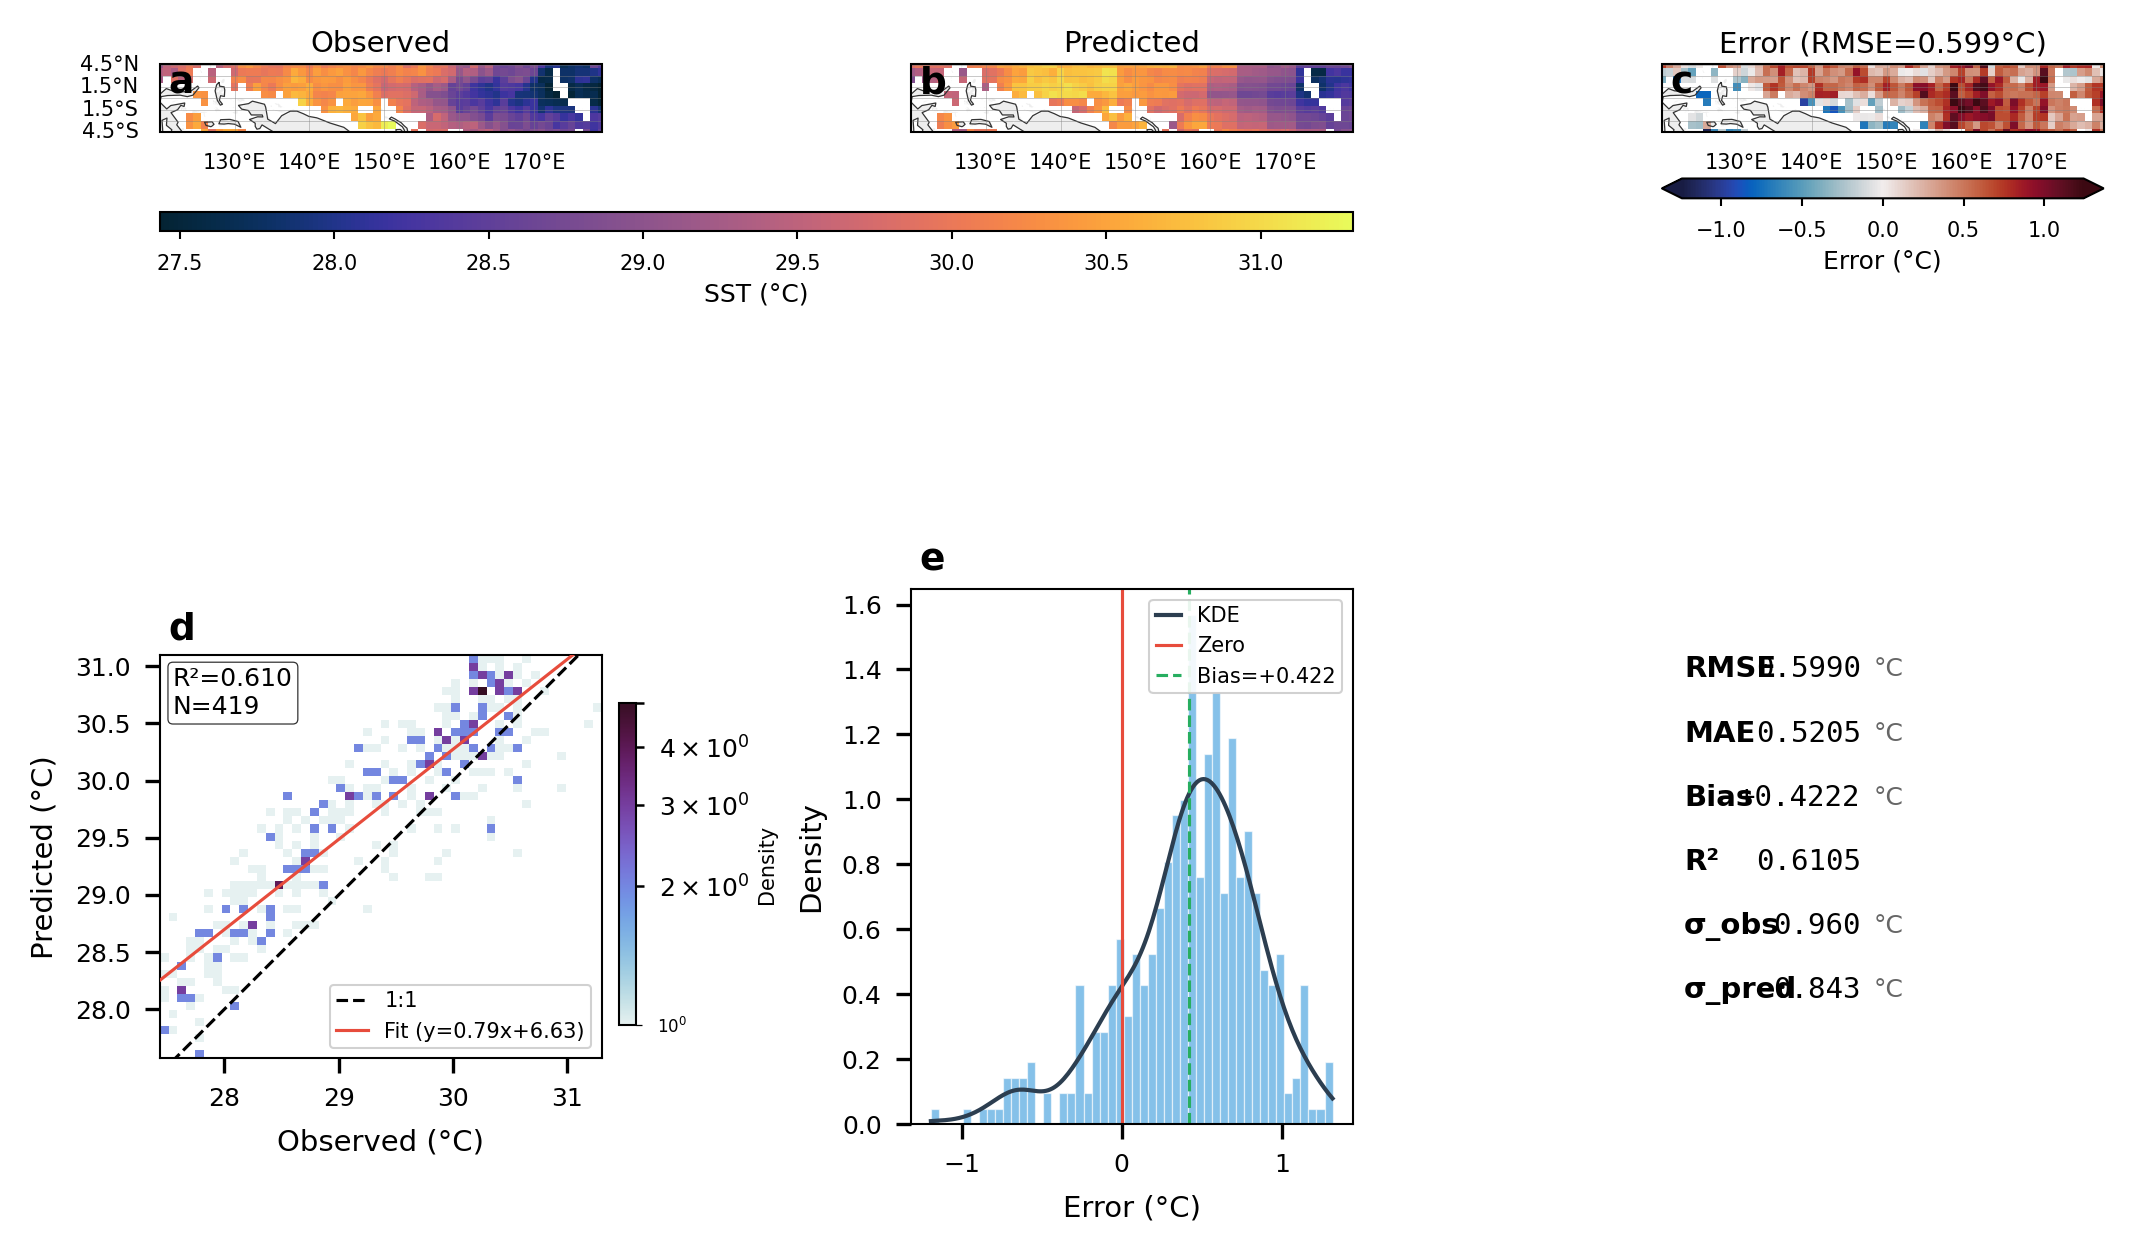

: 

In [ ]:
# %% 2. 区域性分析
# 对关键海洋区域进行针对性分析

from src.analysis.regional import run_regional_analysis

print("=" * 70)
print("🌊 区域性分析")
print("=" * 70)

# 运行区域分析
# detail_regions 可选值：
#   'nino34'（厄尔尼诺监测区）, 'nino3'（东太平洋暖池）, 
#   'warm_pool'（赤道太平洋暖池）, 'gulf_stream'（墨西哥湾暖流）,
#   'kuroshio'（黑潮）, 'acc'（南大洋西风漂流）, 
#   'north_indian'（北印度洋）, 'north_atlantic_subpolar'（北大西洋副极地）

analyzer, stats, summary_df = run_regional_analysis(
    predictor=predictor,
    area=area,
    resolution=resolution,
    test_offset=TEST_OFFSET,
    save_dir='out/sst/regional',
    detail_regions=['nino34', 'gulf_stream', 'kuroshio', 'acc', 'warm_pool'],
    show_plots=True
)

print("\n✅ 区域分析完成！")
